# ⚔️ Support Vector Machine (SVM) Classification

A different optimization goal from every prior algorithm: instead of just finding *any* separating boundary (Logistic Regression) or the majority vote of neighbors (KNN), SVM finds the boundary that maximizes the **margin** — the distance to the closest points of each class — and, via the kernel trick, can bend that boundary into genuinely non-linear shapes without ever explicitly computing new features.

📖 Full mathematical explanation (margin maximization, the dual problem, kernel trick derivation): [README.md](README.md)


## 1. Setup & Dataset


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_circles, make_moons, load_breast_cancer
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
sns.set_theme(style="whitegrid")
np.random.seed(42)


In [3]:
X_2d, y_2d = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=2.0, random_state=42
)


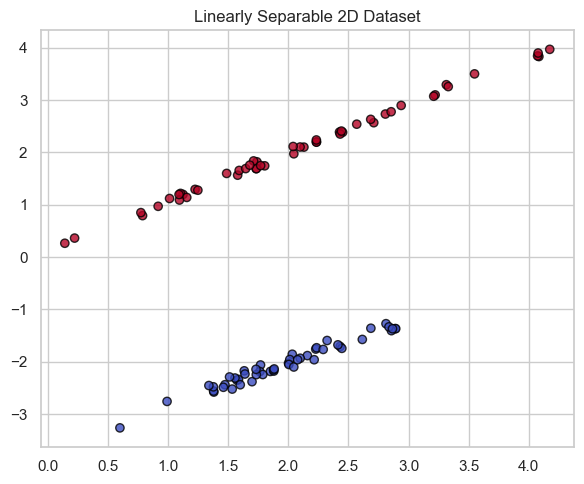

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.8)
ax.set_title("Linearly Separable 2D Dataset")
plt.tight_layout()
plt.show()


## 2. The Margin — Why Maximize It, Not Just Separate

Many different lines can perfectly separate two linearly-separable classes. SVM picks the one **farthest** from both classes — intuitively, the boundary with the most "breathing room," which tends to generalize better to new points near the boundary.


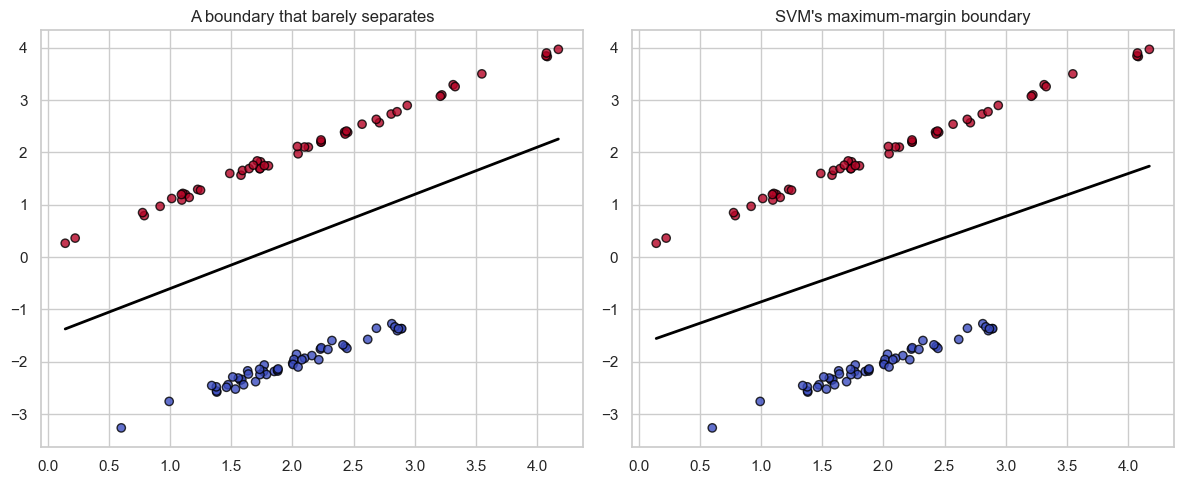

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, title in zip(axes, ["A boundary that barely separates", "SVM's maximum-margin boundary"]):
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.8)
    ax.set_title(title)

# Left: a boundary that technically separates but hugs one class closely
x_line = np.linspace(X_2d[:, 0].min(), X_2d[:, 0].max(), 100)
axes[0].plot(x_line, 0.9 * x_line - 1.5, color="black", linewidth=2)

# Right: SVM's actual boundary, fit properly below
svm_model = SVC(kernel="linear", C=1000).fit(X_2d, y_2d)
w, b = svm_model.coef_[0], svm_model.intercept_[0]
axes[1].plot(x_line, -(w[0] * x_line + b) / w[1], color="black", linewidth=2)
plt.tight_layout()
plt.show()


## 3. Support Vectors — the Only Points That Matter

SVM's boundary is determined *entirely* by the closest points of each class (the "support vectors") — every other point could move anywhere further away without changing the boundary at all. This is a genuinely different property from Logistic Regression, whose boundary shifts with every single point.


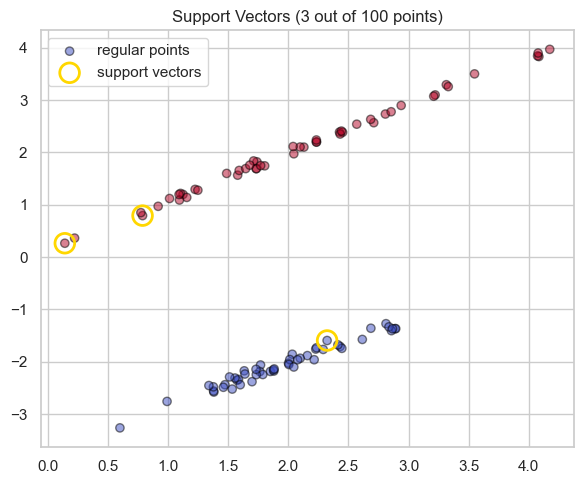

Only 3 of 100 points (3.0%) actually determine the boundary.


In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.5, label="regular points")
ax.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1],
           facecolor="none", edgecolor="gold", s=200, linewidth=2, label="support vectors")
ax.set_title(f"Support Vectors ({len(svm_model.support_vectors_)} out of {len(X_2d)} points)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Only {len(svm_model.support_vectors_)} of {len(X_2d)} points ({len(svm_model.support_vectors_)/len(X_2d):.1%}) actually determine the boundary.")


## 4. Soft Margin — the `C` Parameter

Real data is rarely perfectly separable. **Soft margin** SVM allows some points to violate the margin (or even end up on the wrong side), controlled by `C`: large `C` penalizes violations heavily (narrow margin, fits training data tightly); small `C` tolerates more violations (wider margin, more regularized) — same naming convention as Logistic Regression's `C`.


In [7]:
X_noisy, y_noisy = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.0, flip_y=0.08, random_state=7
)


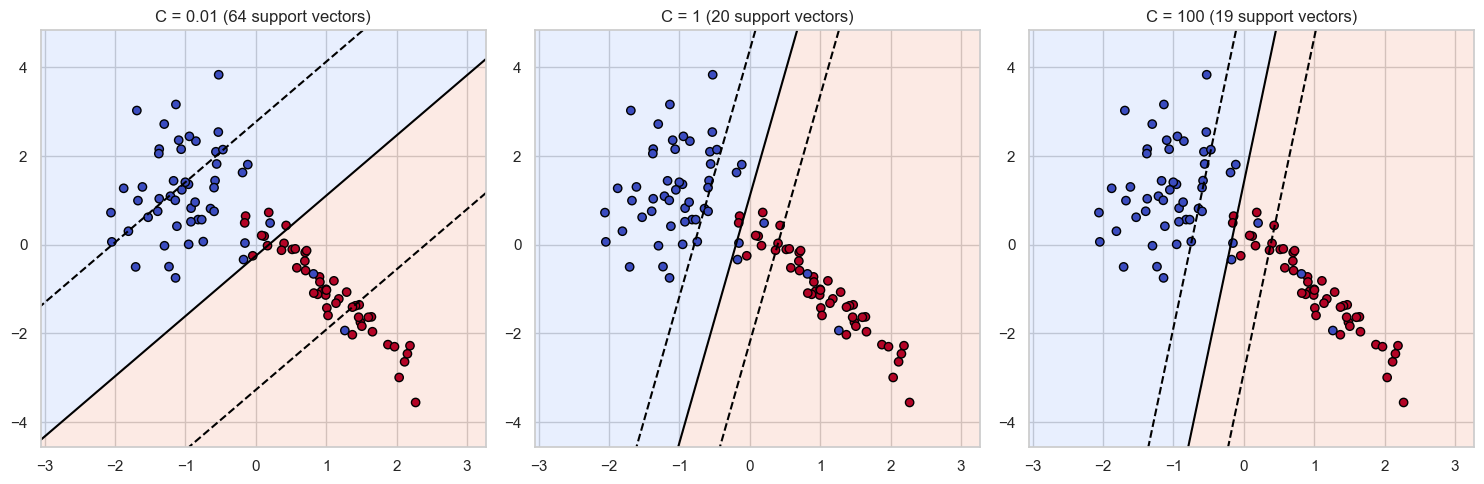

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, C in zip(axes, [0.01, 1, 100]):
    model = SVC(kernel="linear", C=C).fit(X_noisy, y_noisy)
    x_range = np.linspace(X_noisy[:, 0].min() - 1, X_noisy[:, 0].max() + 1, 200)
    y_range = np.linspace(X_noisy[:, 1].min() - 1, X_noisy[:, 1].max() + 1, 200)
    xx, yy = np.meshgrid(x_range, y_range)
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z > 0, alpha=0.2, cmap="coolwarm")
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors="black", linestyles=["--", "-", "--"])
    ax.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_noisy, cmap="coolwarm", edgecolor="black")
    ax.set_title(f"C = {C} ({len(model.support_vectors_)} support vectors)")
plt.tight_layout()
plt.show()


## 5. The Kernel Trick — Handling Non-Linear Data

Real data is often not linearly separable at all — like two concentric circles. The **kernel trick** implicitly maps data into a higher-dimensional space where a linear boundary *does* exist, without ever explicitly computing that mapping.


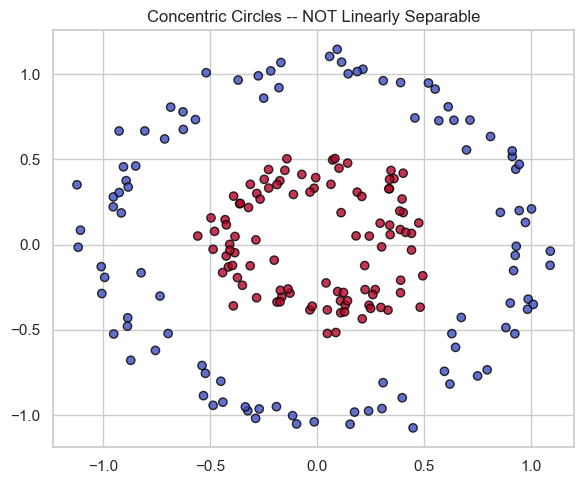

In [9]:
X_circles, y_circles = make_circles(n_samples=200, noise=0.08, factor=0.4, random_state=42)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap="coolwarm", edgecolor="black", alpha=0.8)
ax.set_title("Concentric Circles -- NOT Linearly Separable")
plt.tight_layout()
plt.show()


In [10]:
linear_svm = SVC(kernel="linear").fit(X_circles, y_circles)
print(f"Linear kernel accuracy on this data: {accuracy_score(y_circles, linear_svm.predict(X_circles)):.4f}")
print("-> No straight line can separate concentric circles -- a fundamentally different approach is needed.")


Linear kernel accuracy on this data: 0.5900
-> No straight line can separate concentric circles -- a fundamentally different approach is needed.


## 6. RBF Kernel — Solving the Circles Problem

The RBF (Gaussian) kernel measures similarity based on distance, effectively lifting points into infinite-dimensional space where "inside the circle" and "outside the circle" become linearly separable. Formula in the README.


In [11]:
rbf_svm = SVC(kernel="rbf", C=1, gamma="scale").fit(X_circles, y_circles)
print(f"RBF kernel accuracy: {accuracy_score(y_circles, rbf_svm.predict(X_circles)):.4f}")


RBF kernel accuracy: 1.0000


In [12]:
x_range = np.linspace(X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5, 300)
y_range = np.linspace(X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5, 300)
xx, yy = np.meshgrid(x_range, y_range)
Z = rbf_svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)


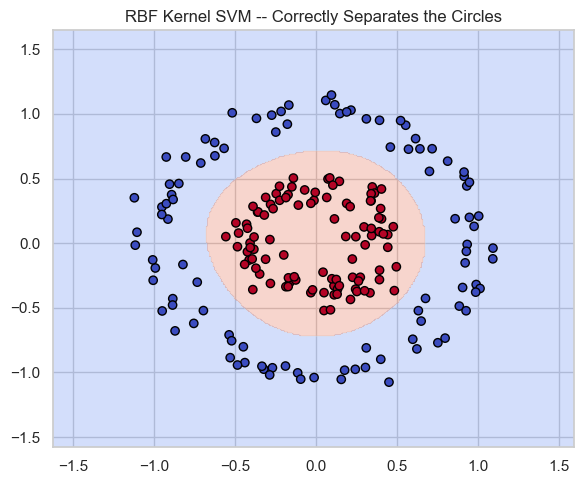

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=2, cmap="coolwarm", alpha=0.3)
ax.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap="coolwarm", edgecolor="black")
ax.set_title("RBF Kernel SVM -- Correctly Separates the Circles")
plt.tight_layout()
plt.show()


## 7. Polynomial Kernel

The polynomial kernel implicitly adds interaction and power terms (like topic 04's `PolynomialFeatures`, but without ever materializing them) — a different way of introducing curvature than RBF's distance-based similarity.


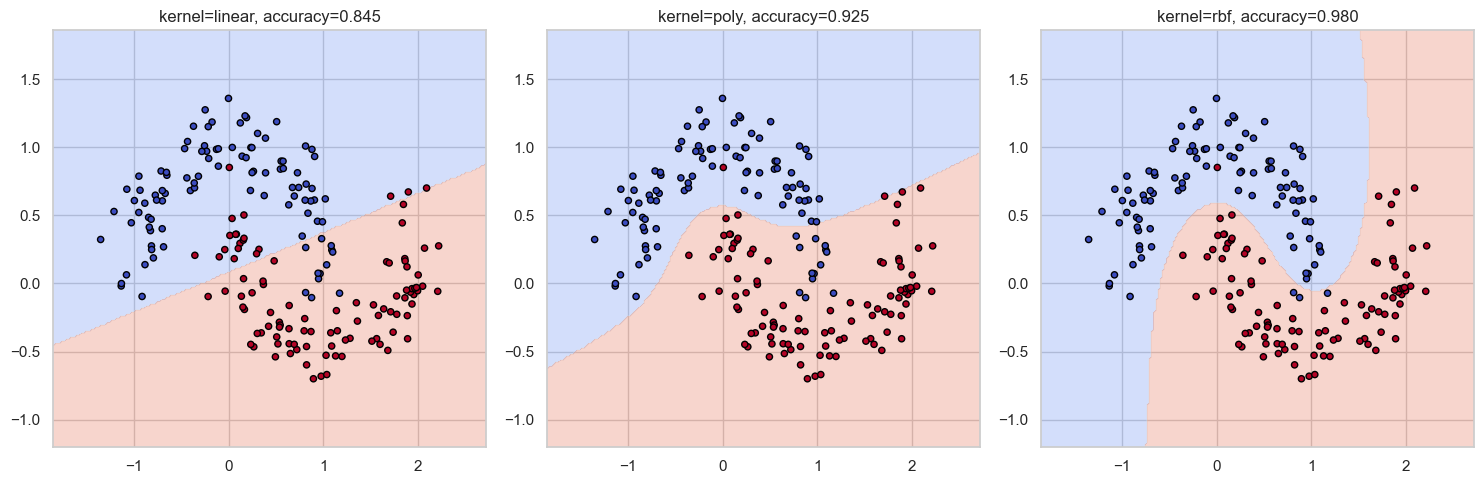

In [14]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.15, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, kernel in zip(axes, ["linear", "poly", "rbf"]):
    model = SVC(kernel=kernel, degree=3, C=1).fit(X_moons, y_moons)
    x_range = np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 200)
    y_range = np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 200)
    xx, yy = np.meshgrid(x_range, y_range)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=2, cmap="coolwarm", alpha=0.3)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="coolwarm", edgecolor="black", s=20)
    acc = accuracy_score(y_moons, model.predict(X_moons))
    ax.set_title(f"kernel={kernel}, accuracy={acc:.3f}")
plt.tight_layout()
plt.show()


## 8. The `gamma` Parameter — RBF Kernel Width

`gamma` controls how far a single training point's influence reaches: small `gamma` means far-reaching, smooth boundaries (closer to linear); large `gamma` means very local influence, tightly wrapping around individual points (risk of overfitting).


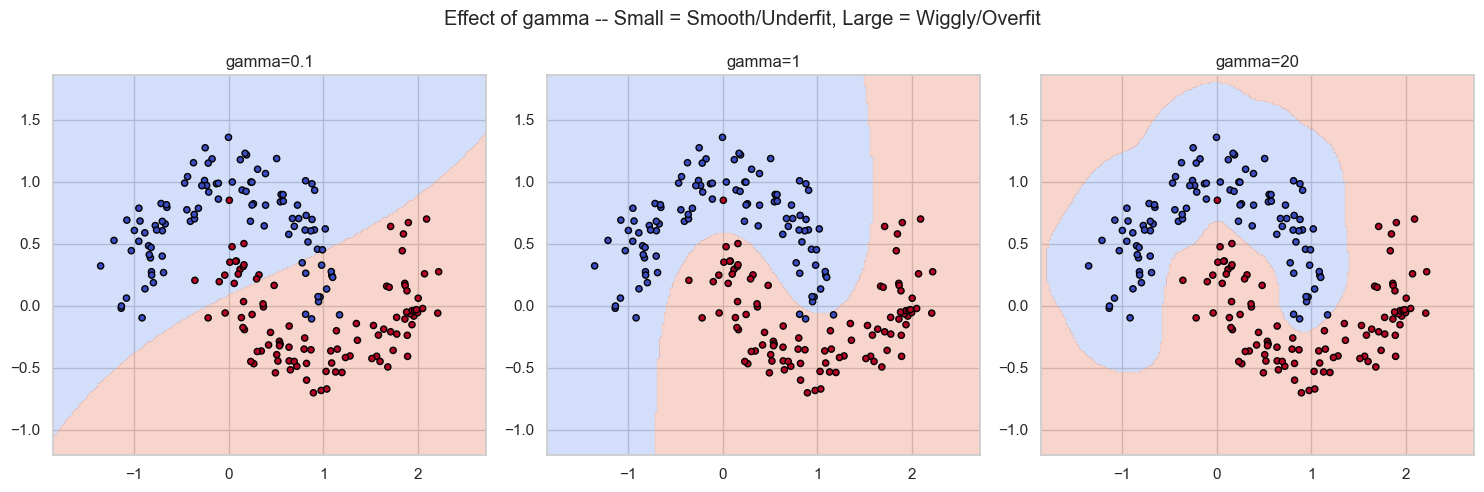

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, gamma in zip(axes, [0.1, 1, 20]):
    model = SVC(kernel="rbf", C=1, gamma=gamma).fit(X_moons, y_moons)
    x_range = np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 200)
    y_range = np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 200)
    xx, yy = np.meshgrid(x_range, y_range)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=2, cmap="coolwarm", alpha=0.3)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="coolwarm", edgecolor="black", s=20)
    ax.set_title(f"gamma={gamma}")
plt.suptitle("Effect of gamma -- Small = Smooth/Underfit, Large = Wiggly/Overfit")
plt.tight_layout()
plt.show()


## 9. Choosing C and gamma via Cross-Validation

With two interacting hyperparameters, a grid search over both (rather than tuning one at a time) is the standard approach — full grid search machinery covered later in Model Evaluation & Tuning; here's the core mechanism applied directly.


In [16]:
from sklearn.model_selection import GridSearchCV
param_grid = {"C": [0.1, 1, 10, 100], "gamma": [0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_moons, y_moons)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with h

In [17]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'C': 1, 'gamma': 10}
Best CV accuracy: 0.9900


In [18]:
results = pd.DataFrame(grid_search.cv_results_)[["param_C", "param_gamma", "mean_test_score"]]
pivot = results.pivot(index="param_C", columns="param_gamma", values="mean_test_score")


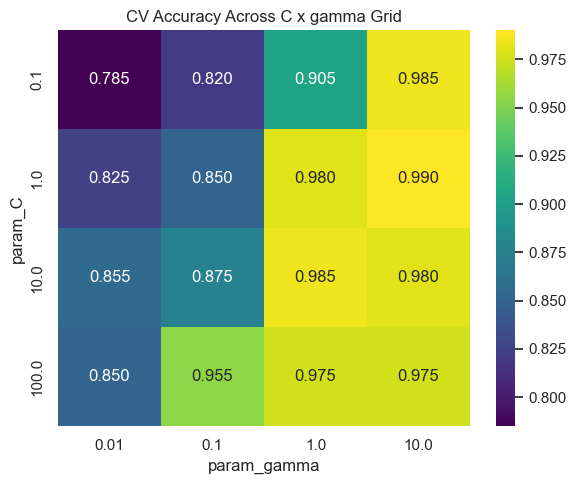

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("CV Accuracy Across C x gamma Grid")
plt.tight_layout()
plt.show()


## 10. Feature Scaling Is Mandatory for SVM

Like KNN, SVM's margin calculation is fundamentally distance-based — an unscaled feature with a larger numeric range distorts the margin exactly as it distorted KNN's distance calculations in the previous category topics.


In [20]:
X_unscaled = np.column_stack([
    np.random.normal(50, 10, 200),
    np.random.normal(50000, 15000, 200),
])
y_unscaled = (X_unscaled[:, 0] > 50).astype(int)


In [21]:
acc_unscaled = cross_val_score(SVC(kernel="rbf"), X_unscaled, y_unscaled, cv=5).mean()
X_scaled = StandardScaler().fit_transform(X_unscaled)
acc_scaled = cross_val_score(SVC(kernel="rbf"), X_scaled, y_unscaled, cv=5).mean()


In [22]:
print(f"Accuracy WITHOUT scaling: {acc_unscaled:.4f}")
print(f"Accuracy WITH scaling:    {acc_scaled:.4f}")


Accuracy WITHOUT scaling: 0.4950
Accuracy WITH scaling:    0.9850


## 11. Multiclass SVM

SVM is inherently a binary classifier; scikit-learn handles multiclass problems via **one-vs-one** (train a binary classifier for every pair of classes, majority vote) — the default strategy for `SVC`.


In [23]:
from sklearn.datasets import make_classification as make_clf
X_multi, y_multi = make_clf(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                              n_classes=3, n_clusters_per_class=1, random_state=42)


In [24]:
multi_svm = SVC(kernel="rbf", decision_function_shape="ovo").fit(X_multi, y_multi)
n_classes = len(np.unique(y_multi))
n_binary_classifiers = n_classes * (n_classes - 1) // 2


In [25]:
print(f"Classes: {n_classes} -> one-vs-one trains {n_binary_classifiers} binary SVMs internally")
print(f"Training accuracy: {accuracy_score(y_multi, multi_svm.predict(X_multi)):.4f}")


Classes: 3 -> one-vs-one trains 3 binary SVMs internally
Training accuracy: 0.8300


## 12. Real Dataset — Breast Cancer with a Tuned RBF SVM


In [26]:
cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = cancer.data, cancer.target


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.2, stratify=y_cancer, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [28]:
svm_grid = GridSearchCV(SVC(kernel="rbf"), {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.1]}, cv=5)
svm_grid.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hig

In [29]:
print(f"Best params: {svm_grid.best_params_}")
best_svm = svm_grid.best_estimator_
test_preds = best_svm.predict(X_test_scaled)
print(f"Test accuracy: {accuracy_score(y_test, test_preds):.4f}")
print("\n", classification_report(y_test, test_preds, target_names=cancer.target_names))


Best params: {'C': 10, 'gamma': 0.01}
Test accuracy: 0.9825

               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 13. Confusion Matrix — Breast Cancer Dataset


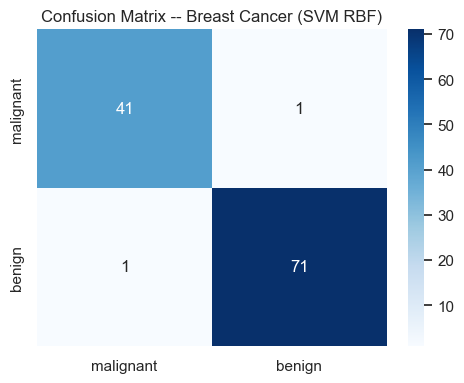

In [30]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
ax.set_title("Confusion Matrix -- Breast Cancer (SVM RBF)")
plt.tight_layout()
plt.show()


## 14. SVM vs Other Classifiers So Far

A quick head-to-head against Logistic Regression, KNN, and Random Forest on the exact same Breast Cancer split — no single algorithm wins every dataset, which is precisely why this series builds a full toolkit instead of just one "best" model.


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF, tuned)": best_svm,
}


In [33]:
results = {}
for name, model in models.items():
    if name != "SVM (RBF, tuned)":
        model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, preds)


In [34]:
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:22s} -> test accuracy: {acc:.4f}")


Logistic Regression    -> test accuracy: 0.9825
SVM (RBF, tuned)       -> test accuracy: 0.9825
KNN (k=5)              -> test accuracy: 0.9561
Random Forest          -> test accuracy: 0.9561


## 15. Linear Kernel vs `LinearSVC` — a Performance Note

`SVC(kernel="linear")` and `LinearSVC` both fit linear boundaries, but use different underlying optimizers — `LinearSVC` scales much better to large datasets since it doesn't compute the full kernel matrix that `SVC` does internally.


In [35]:
import time
X_large, y_large = make_classification(n_samples=3000, n_features=20, random_state=42)


In [36]:
start = time.time()
SVC(kernel="linear").fit(X_large, y_large)
svc_time = time.time() - start


In [37]:
start = time.time()
LinearSVC(max_iter=5000).fit(X_large, y_large)
linearsvc_time = time.time() - start


In [38]:
print(f"SVC(kernel='linear') fit time: {svc_time:.3f}s")
print(f"LinearSVC fit time:            {linearsvc_time:.3f}s")
print("\n-> For a purely linear boundary at scale, LinearSVC is typically the better choice;")
print("   reach for SVC only when you actually need a non-linear kernel (poly/rbf).")


SVC(kernel='linear') fit time: 0.034s
LinearSVC fit time:            0.002s

-> For a purely linear boundary at scale, LinearSVC is typically the better choice;
   reach for SVC only when you actually need a non-linear kernel (poly/rbf).


## ✅ Key Takeaways

- SVM optimizes for the **maximum margin**, not just any separating boundary — a genuinely different objective from every prior algorithm, determined entirely by a small subset of "support vector" points.
- `C` controls the margin/misclassification-tolerance tradeoff (soft margin) — same naming and direction as Logistic Regression's `C`.
- The **kernel trick** (`poly`, `rbf`) lets SVM learn non-linear boundaries without ever explicitly computing higher-dimensional features — RBF solved the concentric-circles problem that a linear kernel provably cannot.
- `gamma` (RBF's width) follows the same bias-variance pattern as KNN's $k$ and tree depth: small = smooth/underfit, large = wiggly/overfit.
- Feature scaling is mandatory, for the same distance-based reasons as KNN.
- No single algorithm dominates every dataset (section 14) — this is the practical justification for the entire multi-algorithm structure of this series, not just a throwaway comment.

**Next up:** [07_LDA_QDA](../07_LDA_QDA/) — a generative approach related to Naive Bayes and PCA's eigenvector math, back to a fully closed-form (no iterative optimization) classifier.
